# Markov-chain LTV from zero to useful

This notebook teaches a different CLV idea from BTYD.

BTYD starts with purchase timing and asks: who is still alive, and how many future purchases should we expect?

A Markov-chain LTV model starts with **customer states** and asks:

> If customers move between states month after month, what future value should we expect from each state?

Inspiration checked: the Tensor House Markov notebook uses four states based on months of silence and projects revenue through a transition matrix. Here we use **monthly engagement tiers** instead — the Pfeifer–Carraway style of segment-migration model — and tell the idea more slowly, with data, estimation, interpretation, validation checks, uncertainty estimates, and a business intervention scenario.

## 1. The idea in one sentence

A Markov chain says:

> The next state depends on the current state, not the whole past.

For LTV, we score every customer every month into a **monthly engagement tier** — the segment-migration idea popularized by Pfeifer and Carraway (2000). The tiers are re-scored fresh each month from that month's behavior:

- `New`: recently acquired, still onboarding. A customer can persist here for a month or two while they settle in (which is why the matrix below has a small `New -> New` probability), then migrates to another tier.
- `Active`: highly engaged this month — multiple or large purchases.
- `Warm`: lightly engaged this month — some small purchase activity.
- `Cooling`: minimal engagement this month — an occasional tiny purchase.
- `Dormant`: barely engaged — a rare small purchase at most.
- `Churned`: gone. Absorbing state: we stop expecting future value.

Two consequences of this definition matter for everything below:

1. **Every non-churned tier can generate some revenue.** These are engagement levels, not months-of-silence counters, so `Warm`, `Cooling`, and even `Dormant` months carry small positive expected margin. That is why the reward vector later in the notebook has nonzero entries for those states.
2. **Any tier-to-tier move is possible month to month.** Because tiers are re-scored each month, a customer can stay `Warm` two months running (the estimated matrix gives that move a probability of about 0.27) or drop from `Active` straight to `Dormant`. If the states were strict months-of-silence buckets, most of those moves would be mechanically impossible — the free-form transition matrix below only makes sense for engagement tiers.

Once we know the probability of moving between tiers, we can forecast future customer counts and expected profit.

### A caveat before we start: "Churned" is a label, not an observation

In real non-contractual data nobody tells you a customer is gone. "Churned" is an **operational definition** — a recency cutoff ("no engagement for N months"), an account closure, an unsubscribe — not an observed death. That unobservability is exactly the problem BTYD models attack with a latent alive/dead state. Treating `Churned` as absorbing is therefore a modeling convention, not a fact: customers written off as churned do come back. In practice you should check the sensitivity of the LTV results to (a) the churn definition itself and (b) allowing a small `Churned -> Active` resurrection probability. In this notebook the simulator makes churn genuinely absorbing, so the convention is harmless here — but only here.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Silence only known-noisy third-party warning categories instead of a blanket
# ignore, so genuine problems in our own code stay visible.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260704
rng = np.random.default_rng(RANDOM_SEED)

## 2. Generate a customer-month dataset

We will simulate monthly customer states for a small ecommerce brand.

Each row means:

> customer X was in engagement tier Y during month T and generated this much gross margin.

Consistent with the tier definitions above, every non-churned tier earns *some* margin on average — `Active` the most, `Dormant` a trickle.

In a real project, these tiers come from a monthly scoring rule built on order history, product usage, subscription status, or RFM segments.

In [2]:
states = ["New", "Active", "Warm", "Cooling", "Dormant", "Churned"]
state_to_idx = {s: i for i, s in enumerate(states)}

# True transition matrix used only to generate synthetic data.
P_true = pd.DataFrame(
    [
        [0.08, 0.58, 0.24, 0.07, 0.02, 0.01],
        [0.00, 0.62, 0.25, 0.08, 0.03, 0.02],
        [0.00, 0.34, 0.26, 0.24, 0.10, 0.06],
        [0.00, 0.18, 0.16, 0.28, 0.24, 0.14],
        [0.00, 0.08, 0.08, 0.14, 0.38, 0.32],
        [0.00, 0.00, 0.00, 0.00, 0.00, 1.00],
    ],
    index=states,
    columns=states,
)

monthly_margin_by_state = {
    "New": 8,
    "Active": 34,
    "Warm": 16,
    "Cooling": 7,
    "Dormant": 2,
    "Churned": 0,
}

n_customers = 1800
n_months = 18
rows = []

for customer_num in range(1, n_customers + 1):
    customer_id = f"M{customer_num:05d}"
    state = "New"
    for month in range(n_months):
        margin_mean = monthly_margin_by_state[state]
        margin = 0 if margin_mean == 0 else rng.gamma(shape=3.0, scale=margin_mean / 3.0)
        rows.append({"customer_id": customer_id, "month": month, "state": state, "gross_margin": round(float(margin), 2)})
        probs = P_true.loc[state].values
        state = rng.choice(states, p=probs)

customer_month = pd.DataFrame(rows)
customer_month.head()

,customer_id,month,state,gross_margin
0,M00001,0,New,3.40
1,M00001,1,Active,23.72
2,M00001,2,Warm,15.78
3,M00001,3,Warm,25.58
4,M00001,4,Churned,0.00


In [3]:
state_counts = customer_month.pivot_table(index="month", columns="state", values="customer_id", aggfunc="count", fill_value=0)
state_counts = state_counts.reindex(columns=states, fill_value=0)
state_counts.head(10)

state,New,Active,Warm,Cooling,Dormant,Churned
month,,,,,,
0,1800,0,0,0,0,0
1,147,1059,429,108,41,16
2,12,897,465,236,107,83
3,2,753,419,255,177,194
4,0,667,346,268,208,311
5,0,594,324,237,199,446
6,0,523,312,217,182,566
7,0,485,266,202,172,675
8,0,438,241,184,157,780


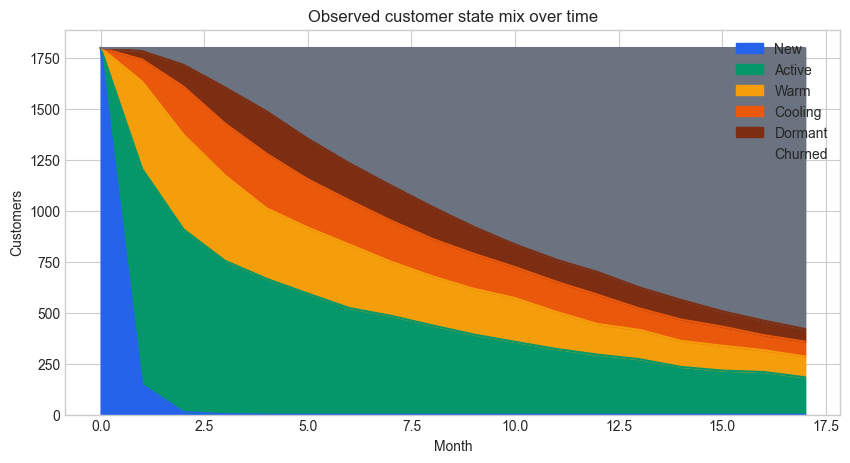

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
state_counts.plot.area(ax=ax, color=["#2563EB", "#059669", "#F59E0B", "#EA580C", "#7C2D12", "#6B7280"])
ax.set_title("Observed customer state mix over time")
ax.set_xlabel("Month")
ax.set_ylabel("Customers")
ax.legend(loc="upper right")
plt.show()

## 3. Estimate the transition matrix from data

A transition matrix has one row per current state and one column per next state.

Each row must sum to 1.

Example interpretation (hypothetical number, for reading practice only):

> If a `Warm -> Active` probability were 0.30, about 30% of warm customers would be expected to become active next month. Our actual estimate below puts `Warm -> Active` at roughly 0.34.

We also display the raw **transition counts** next to the probabilities: the counts show how much data supports each row, which matters when we talk about uncertainty later.

In [5]:
next_month = customer_month.copy()
next_month["month"] = next_month["month"] - 1
transitions = customer_month.merge(
    next_month[["customer_id", "month", "state"]].rename(columns={"state": "next_state"}),
    on=["customer_id", "month"],
    how="inner",
)


def estimate_transition_matrix(transitions_df, absorbing=("Churned",)):
    """Turn observed (state, next_state) pairs into a row-stochastic matrix.

    A never-visited state would silently produce a non-stochastic all-zero row
    if we just divided row counts and filled NaNs with 0, so we assert support
    explicitly and fail loudly instead.
    """
    counts = pd.crosstab(transitions_df["state"], transitions_df["next_state"]).reindex(
        index=states, columns=states, fill_value=0
    )
    row_support = counts.sum(axis=1)
    unvisited = [s for s in states if s not in absorbing and row_support[s] == 0]
    if unvisited:
        raise ValueError(
            f"No observed transitions out of non-absorbing state(s) {unvisited}; "
            "the estimate would contain non-stochastic rows. Merge or drop these states."
        )
    P = counts.div(row_support.replace(0, np.nan), axis=0)
    for s in absorbing:
        # Absorbing rows are set programmatically from the state list (identity row).
        P.loc[s] = [1.0 if col == s else 0.0 for col in states]
    return counts, P


transition_counts, P_hat = estimate_transition_matrix(transitions)

print("Transition counts (row support: how much data backs each row):")
display(transition_counts)
print("Row sums of P_hat (each must equal 1):")
display(P_hat.sum(axis=1).round(6).to_frame("row_sum"))
P_hat.round(3)

Transition counts (row support: how much data backs each row):


next_state,New,Active,Warm,Cooling,Dormant,Churned
state,,,,,,
New,161,1155,465,121,42,17
Active,0,4694,2029,615,234,141
Warm,0,1385,1083,969,406,232
Cooling,0,494,431,778,665,333
Dormant,0,168,169,291,765,657
Churned,0,0,0,0,0,12100


Row sums of P_hat (each must equal 1):


,row_sum
state,
New,1.0
Active,1.0
Warm,1.0
Cooling,1.0
Dormant,1.0
Churned,1.0


next_state,New,Active,Warm,Cooling,Dormant,Churned
state,,,,,,
New,0.082,0.589,0.237,0.062,0.021,0.009
Active,0.000,0.609,0.263,0.080,0.030,0.018
Warm,0.000,0.340,0.266,0.238,0.100,0.057
Cooling,0.000,0.183,0.160,0.288,0.246,0.123
Dormant,0.000,0.082,0.082,0.142,0.373,0.320
Churned,0.000,0.000,0.000,0.000,0.000,1.000


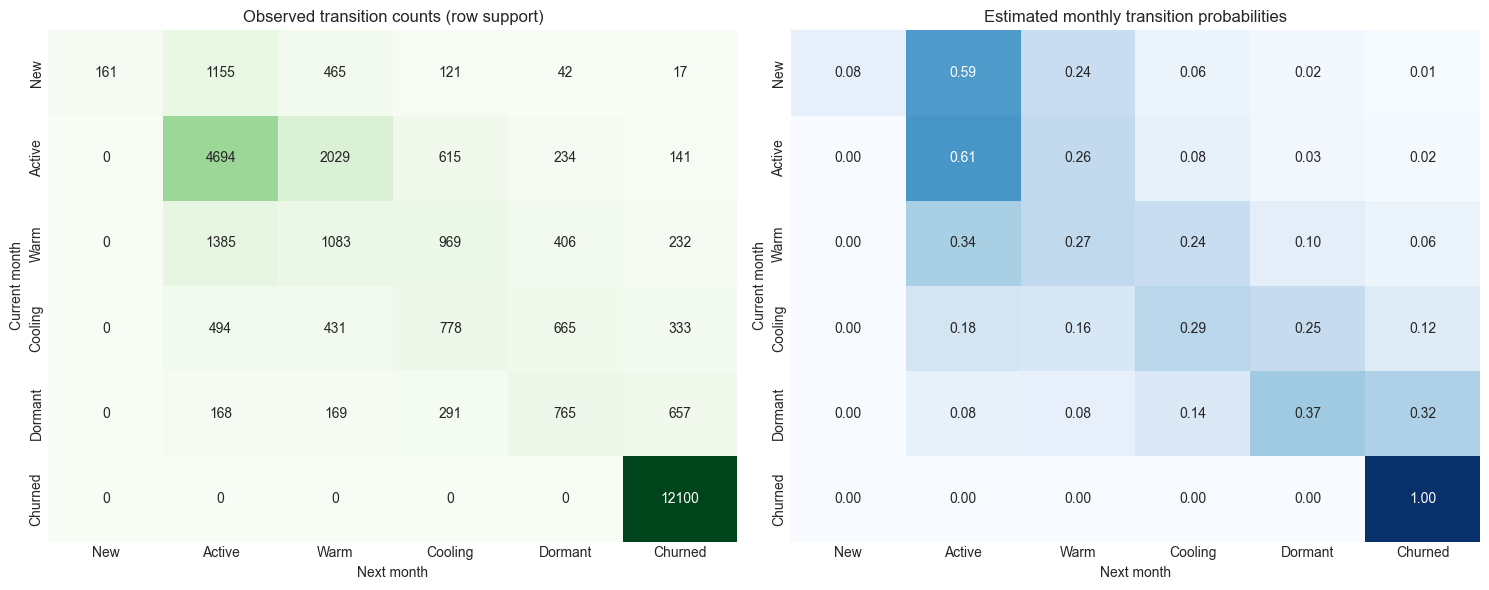

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(transition_counts, annot=True, fmt="d", cmap="Greens", ax=axes[0], cbar=False)
axes[0].set_title("Observed transition counts (row support)")
axes[0].set_xlabel("Next month")
axes[0].set_ylabel("Current month")
sns.heatmap(P_hat, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Estimated monthly transition probabilities")
axes[1].set_xlabel("Next month")
axes[1].set_ylabel("Current month")
plt.tight_layout()
plt.show()

## 4. Validation checks

The intro promised validation, so let us actually validate. Two checks:

1. **Recovery check (only possible with synthetic data).** We know the true matrix `P_true` that generated the data, so we can measure how far the estimate `P_hat` is from it.
2. **Temporal holdout backtest (always possible, and the one that matters on real data).** Estimate the matrix on the first 12 months only, project state counts forward over the last 6 months, and compare with what actually happened.

One honest caveat before celebrating: this dataset was generated by a process that is *exactly* first-order Markov and time-homogeneous, so passing these checks demonstrates that the estimation mechanics work — it says nothing about whether a Markov model is adequate for real customers, where both assumptions routinely fail.

In [7]:
deviation = P_hat - P_true
print(f"Max  |P_hat - P_true| entry: {deviation.abs().values.max():.4f}")
print(f"Mean |P_hat - P_true| entry: {deviation.abs().values.mean():.4f}")
deviation.round(3)

Max  |P_hat - P_true| entry: 0.0167
Mean |P_hat - P_true| entry: 0.0031


next_state,New,Active,Warm,Cooling,Dormant,Churned
state,,,,,,
New,0.002,0.009,-0.003,-0.008,0.001,-0.001
Active,0.000,-0.011,0.013,-0.000,0.000,-0.002
Warm,0.000,-0.000,0.006,-0.002,-0.000,-0.003
Cooling,0.000,0.003,-0.000,0.008,0.006,-0.017
Dormant,0.000,0.002,0.002,0.002,-0.007,0.000
Churned,0.000,0.000,0.000,0.000,0.000,0.000


With roughly 30,600 observed transition pairs, every estimated probability lands within about 0.017 of the truth (mean absolute error about 0.003) — pure sampling noise.

### Temporal holdout backtest

Now the check you can run on real data: re-estimate the transition matrix using **months 0–11 only**, start from the observed month-11 state counts, and project months 12–17 by repeated multiplication with the holdout matrix. If the model is any good, projected counts should track actual counts.

In [8]:
train_transitions = transitions[transitions["month"] <= 10]  # from-months 0..10, so only months 0-11 are used
train_counts, P_train = estimate_transition_matrix(train_transitions)
print(f"Training transition pairs: {len(train_transitions):,} (months 0-11); holdout: months 12-17")

dist = state_counts.loc[11].values.astype(float)  # observed month-11 snapshot
projected = {}
for month in range(12, 18):
    dist = dist @ np.asarray(P_train, dtype=float)
    projected[month] = dist.copy()
projected = pd.DataFrame(projected, index=states).T.rename_axis(index="month", columns=None)

actual = state_counts.loc[12:17].rename_axis(index="month", columns=None)
errors = projected - actual
mae_by_month = errors.abs().mean(axis=1)

display(pd.concat({"actual": actual, "projected": projected.round(1)}, axis=1))
print("MAE across the six states, by projected month (customers):")
display(mae_by_month.round(1).to_frame("mae_customers"))
print(
    f"Overall MAE: {errors.abs().values.mean():.1f} customers per state-month; "
    f"largest single miss: {errors.abs().values.max():.0f} customers; "
    f"cohort size: {int(state_counts.loc[11].sum())}."
)

Training transition pairs: 19,800 (months 0-11); holdout: months 12-17


actual                                     projected                                      
         New Active Warm Cooling Dormant Churned       New Active   Warm Cooling Dormant Churned
month                                                                                           
12         0    294  150     144     111    1101       0.0  293.0  167.1   127.0   103.9  1109.0
13         0    272  144     105     103    1176       0.0  266.2  151.8   114.5    94.9  1172.6
14         0    234  128     105      96    1237       0.0  241.7  137.8   103.8    86.2  1230.5
15         0    216  122      94      75    1293       0.0  219.4  125.1    94.2    78.2  1283.1
16         0    209  107      74      71    1339       0.0  199.2  113.5    85.5    71.0  1330.8
17         0    183  102      73      62    1380       0.0  180.8  103.1    77.6    64.4  1374.1

MAE across the six states, by projected month (customers):


,mae_customers
month,
12,8.4
13,5.8
14,5.8
15,3.3
16,6.0
17,2.7


Overall MAE: 5.3 customers per state-month; largest single miss: 17 customers; cohort size: 1800.


Six months out, the projection is off by only about 5 customers per state per month on a cohort of 1,800 — the transition matrix estimated on the first year forecasts the second half-year well. (As cautioned above, part of this success is circular: the data really is Markov. On real data this backtest is where model inadequacy shows up first.)

## 5. Rewards: how states become money

A Markov chain tells us where customers move. LTV also needs money.

We estimate a reward vector:

> expected gross margin earned during one month in each state.

The reward can be revenue, gross margin, contribution profit, or margin minus marketing cost. For serious work, use contribution margin rather than raw revenue.

In [9]:
reward = customer_month.groupby("state")["gross_margin"].mean().reindex(states).fillna(0)
reward.loc["Churned"] = 0
reward.to_frame("expected_monthly_margin").round(2)

,expected_monthly_margin
state,
New,7.89
Active,34.03
Warm,15.93
Cooling,7.00
Dormant,1.99
Churned,0.00


## 6. Finite-horizon Markov LTV

Let `P` be the transition matrix and `r` be the reward vector.

Starting from a state today, expected value over the next `H` months is:

`r + d P r + d^2 P^2 r + ... + d^(H-1) P^(H-1) r`

where `d` is a monthly discount factor.

The formula looks intimidating, but it is just repeated forecasting:

- month 0: collect current reward.
- month 1: move customers using `P`, collect expected reward.
- month 2: move again, collect expected reward.
- repeat.

In [10]:
def finite_horizon_ltv(P, reward, horizon_months=24, monthly_discount_rate=0.01):
    P_arr = np.asarray(P, dtype=float)
    r = np.asarray(reward, dtype=float).reshape(-1, 1)
    discount = 1 / (1 + monthly_discount_rate)

    values = np.zeros((P_arr.shape[0], 1))
    state_distribution = np.eye(P_arr.shape[0])
    for t in range(horizon_months):
        values += (discount ** t) * state_distribution @ r
        state_distribution = state_distribution @ P_arr
    return pd.Series(values.ravel(), index=P.index, name=f"ltv_{horizon_months}m")

ltv_24 = finite_horizon_ltv(P_hat, reward, horizon_months=24, monthly_discount_rate=0.01)
ltv_24.to_frame().round(2)

,ltv_24m
state,
New,211.88
Active,233.21
Warm,180.99
Cooling,136.28
Dormant,85.61
Churned,0.00


In [11]:
horizons = [1, 3, 6, 12, 24, 36]
ltv_by_horizon = pd.concat(
    [finite_horizon_ltv(P_hat, reward, h, monthly_discount_rate=0.01).rename(f"{h}m") for h in horizons],
    axis=1,
)
ltv_by_horizon.round(2)

,1m,3m,6m,12m,24m,36m
state,,,,,,
New,7.89,54.24,103.67,163.81,211.88,225.14
Active,34.03,80.13,127.96,186.44,233.21,246.11
Warm,15.93,49.72,89.95,140.49,180.99,192.16
Cooling,7.00,30.09,61.98,103.19,136.28,145.41
Dormant,1.99,14.95,35.76,63.38,85.61,91.74
Churned,0.00,0.00,0.00,0.00,0.00,0.00


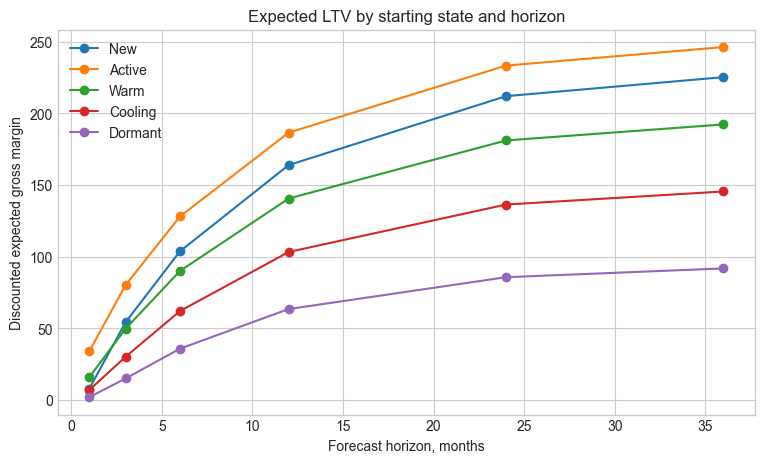

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for state in states[:-1]:
    ax.plot(horizons, ltv_by_horizon.loc[state], marker="o", label=state)
ax.set_title("Expected LTV by starting state and horizon")
ax.set_xlabel("Forecast horizon, months")
ax.set_ylabel("Discounted expected gross margin")
ax.legend()
plt.show()

## 7. Infinite-horizon shortcut

If the discount factor is below 1, we can compute discounted long-run value with a matrix inverse:

`V = (I - dP)^(-1) r`

This is the matrix version of a geometric series.

It is useful because it gives the total discounted future value from each state without manually looping through many months.

In [13]:
def infinite_horizon_ltv(P, reward, monthly_discount_rate=0.01):
    P_arr = np.asarray(P, dtype=float)
    r = np.asarray(reward, dtype=float)
    discount = 1 / (1 + monthly_discount_rate)
    I = np.eye(P_arr.shape[0])
    values = np.linalg.solve(I - discount * P_arr, r)
    return pd.Series(values, index=P.index, name="discounted_infinite_ltv")

ltv_infinite = infinite_horizon_ltv(P_hat, reward, monthly_discount_rate=0.01)
pd.concat([ltv_24, ltv_infinite], axis=1).round(2)

,ltv_24m,discounted_infinite_ltv
state,,
New,211.88,230.20
Active,233.21,251.02
Warm,180.99,196.42
Cooling,136.28,148.88
Dormant,85.61,94.07
Churned,0.00,0.00


## 8. Portfolio forecast

The same transition matrix can forecast customer counts.

If `n0` is the current number of customers in each state, then:

- next month: `n1 = n0 P`
- two months: `n2 = n0 P^2`

This is useful for finance planning because it connects LTV to customer equity: total expected value of the portfolio.

Scoping note: this 12-month projection prices the **existing** book of customers only — it assumes zero future acquisition, so it is a statement about current customer equity, not a company revenue forecast. (In our simulation all 1,800 customers were acquired at month 0, which is also why the `New` row of the snapshot below is empty.)

In [14]:
current_month = customer_month[customer_month["month"] == customer_month["month"].max()]
current_counts = current_month["state"].value_counts().reindex(states, fill_value=0)
current_counts.to_frame("customers_now")

,customers_now
state,
New,0
Active,183
Warm,102
Cooling,73
Dormant,62
Churned,1380


In [15]:
def forecast_counts(current_counts, P, horizon=12):
    dist = current_counts.values.astype(float).reshape(1, -1)
    rows = []
    for t in range(horizon + 1):
        rows.append(pd.Series(dist.ravel(), index=P.columns, name=t))
        dist = dist @ np.asarray(P, dtype=float)
    # rename_axis drops the leftover "next_state" column label inherited from P's columns.
    return pd.DataFrame(rows).rename_axis(index="months_from_now", columns=None)

count_forecast = forecast_counts(current_counts, P_hat, horizon=12)
count_forecast.head()

,New,Active,Warm,Cooling,Dormant,Churned
months_from_now,,,,,,
0,0.0,183.000000,102.000000,73.000000,62.000000,1380.000000
1,0.0,164.470485,92.008501,68.674325,56.823938,1418.022751
2,0.0,148.582525,83.361714,62.840250,52.269752,1452.945760
3,0.0,134.534291,75.577771,57.190356,47.790373,1484.907209
4,0.0,121.938762,68.542663,51.956001,43.526037,1514.036537


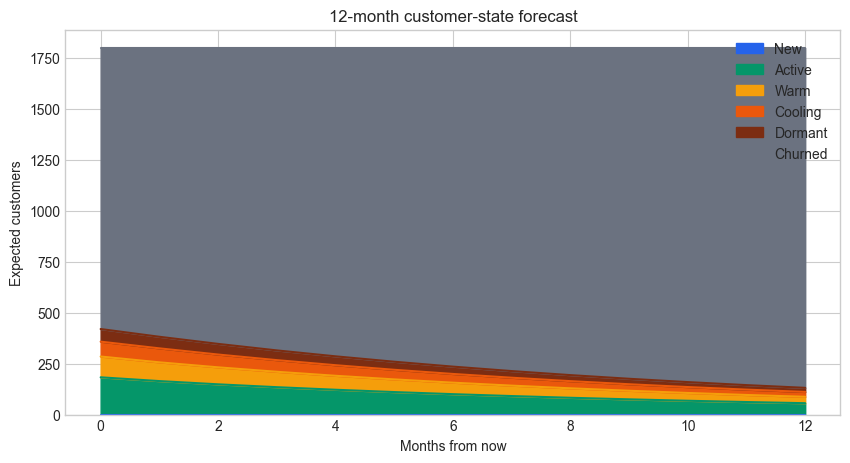

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
count_forecast[states].plot.area(ax=ax, color=["#2563EB", "#059669", "#F59E0B", "#EA580C", "#7C2D12", "#6B7280"])
ax.set_title("12-month customer-state forecast")
ax.set_xlabel("Months from now")
ax.set_ylabel("Expected customers")
ax.legend(loc="upper right")
plt.show()

In [17]:
portfolio_ltv = float(current_counts.values @ ltv_infinite.values)
print(f"Discounted expected value of current portfolio: {portfolio_ltv:,.0f}")

Discounted expected value of current portfolio: 82,673


## 9. Intervention scenario: improve dormant reactivation

Markov LTV is especially handy for scenario planning.

Suppose customer success launches a win-back campaign for `Dormant` customers. We believe it can move some probability mass from `Dormant -> Churned` into `Dormant -> Active`.

We can edit the transition matrix and reprice the portfolio — with two refinements over the naive version of this exercise:

- **The campaign costs money.** We assume the program costs \$1.50 per `Dormant` customer per month while they stay `Dormant` (outreach plus incentive, amortized). Under the campaign, the `Dormant` reward drops by that amount, and we report **net** uplift alongside gross.
- **The assumed effect is a guess.** The headline scenario shifts 8 points of probability from `Dormant -> Churned` to `Dormant -> Active`; a small sensitivity loop shows how the answer moves for weaker campaigns.

In [18]:
CAMPAIGN_MONTHLY_COST_PER_DORMANT = 1.50  # assumed cost per Dormant customer per month, while Dormant
DORMANT_CHURN_SHIFT = 0.08                # assumed mass moved from Dormant->Churned into Dormant->Active

P_campaign = P_hat.copy()
shift = min(DORMANT_CHURN_SHIFT, P_campaign.loc["Dormant", "Churned"])
P_campaign.loc["Dormant", "Churned"] -= shift
P_campaign.loc["Dormant", "Active"] += shift

reward_campaign = reward.copy()
reward_campaign.loc["Dormant"] -= CAMPAIGN_MONTHLY_COST_PER_DORMANT

ltv_campaign_gross = infinite_horizon_ltv(P_campaign, reward, monthly_discount_rate=0.01)
ltv_campaign_net = infinite_horizon_ltv(P_campaign, reward_campaign, monthly_discount_rate=0.01)

comparison = pd.DataFrame({
    "baseline_ltv": ltv_infinite,
    "campaign_ltv_gross": ltv_campaign_gross,
    "campaign_ltv_net": ltv_campaign_net,
    "incremental_net": ltv_campaign_net - ltv_infinite,
}).round(2)
comparison

,baseline_ltv,campaign_ltv_gross,campaign_ltv_net,incremental_net
state,,,,
New,230.20,260.22,257.96,27.76
Active,251.02,280.97,278.71,27.69
Warm,196.42,226.83,224.53,28.12
Cooling,148.88,180.27,177.90,29.02
Dormant,94.07,144.16,140.38,46.31
Churned,0.00,0.00,0.00,0.00


In [19]:
portfolio_ltv_campaign_gross = float(current_counts.values @ ltv_campaign_gross.values)
portfolio_ltv_campaign_net = float(current_counts.values @ ltv_campaign_net.values)
gross_uplift = portfolio_ltv_campaign_gross - portfolio_ltv
net_uplift = portfolio_ltv_campaign_net - portfolio_ltv

print(f"Baseline portfolio value:          {portfolio_ltv:>10,.0f}")
print(f"Campaign portfolio value (gross):  {portfolio_ltv_campaign_gross:>10,.0f}")
print(f"Campaign portfolio value (net):    {portfolio_ltv_campaign_net:>10,.0f}")
print(f"Gross uplift (ignoring cost):      {gross_uplift:>10,.0f}")
print(f"Net uplift (after campaign cost):  {net_uplift:>10,.0f}")

print("\nSensitivity to the assumed Dormant->Churned shift:")
for assumed_shift in [0.02, 0.05, 0.08]:
    P_s = P_hat.copy()
    s = min(assumed_shift, P_s.loc["Dormant", "Churned"])
    P_s.loc["Dormant", "Churned"] -= s
    P_s.loc["Dormant", "Active"] += s
    v_gross = infinite_horizon_ltv(P_s, reward, monthly_discount_rate=0.01)
    v_net = infinite_horizon_ltv(P_s, reward_campaign, monthly_discount_rate=0.01)
    g = float(current_counts.values @ (v_gross - ltv_infinite).values)
    n = float(current_counts.values @ (v_net - ltv_infinite).values)
    print(f"  shift={s:.2f}: gross uplift {g:>8,.0f}   net uplift {n:>8,.0f}")

Baseline portfolio value:              82,673
Campaign portfolio value (gross):      96,652
Campaign portfolio value (net):        95,597
Gross uplift (ignoring cost):          13,979
Net uplift (after campaign cost):      12,925

Sensitivity to the assumed Dormant->Churned shift:
  shift=0.02: gross uplift    3,208   net uplift    2,240
  shift=0.05: gross uplift    8,363   net uplift    7,354
  shift=0.08: gross uplift   13,979   net uplift   12,925


## 10. Uncertainty: bootstrap confidence intervals

`P_hat` is an estimate from a finite sample, so every LTV number downstream inherits sampling noise. The count matrix in section 3 already shows where the noise lives: rows with thin support (`Dormant` has about 2,050 observed transitions; `Active` about 7,700) are estimated less precisely.

To quantify it, we bootstrap **customers**, not rows: resample the 1,800 customers with replacement, re-estimate the transition matrix and the reward vector from the resampled histories, and recompute the infinite-horizon LTVs and the campaign uplift. Resampling whole customers keeps each customer's months together, which respects the within-customer dependence.

In [20]:
N_BOOT = 400
boot_rng = np.random.default_rng(RANDOM_SEED + 1)  # separate stream; the simulator seed is untouched

n_states = len(states)
churned_idx = state_to_idx["Churned"]
dormant_idx = state_to_idx["Dormant"]
active_idx = state_to_idx["Active"]

# Pre-aggregate per customer so each bootstrap replicate is a cheap row-sum.
cust_pos, cust_ids = pd.factorize(transitions["customer_id"])
flat_pair = transitions["state"].map(state_to_idx).values * n_states + transitions["next_state"].map(state_to_idx).values
per_cust_trans = np.zeros((len(cust_ids), n_states * n_states))
np.add.at(per_cust_trans, (cust_pos, flat_pair), 1.0)

cm_pos = customer_month["customer_id"].map(pd.Series(range(len(cust_ids)), index=cust_ids)).values
cm_state = customer_month["state"].map(state_to_idx).values
per_cust_margin = np.zeros((len(cust_ids), n_states))
per_cust_visits = np.zeros((len(cust_ids), n_states))
np.add.at(per_cust_margin, (cm_pos, cm_state), customer_month["gross_margin"].values)
np.add.at(per_cust_visits, (cm_pos, cm_state), 1.0)

discount = 1 / 1.01
identity = np.eye(n_states)
counts_now = current_counts.values.astype(float)

ltv_boot = np.zeros((N_BOOT, n_states))
gross_uplift_boot = np.zeros(N_BOOT)
net_uplift_boot = np.zeros(N_BOOT)

for b in range(N_BOOT):
    sample = boot_rng.integers(0, len(cust_ids), len(cust_ids))  # customers, with replacement

    counts_b = per_cust_trans[sample].sum(axis=0).reshape(n_states, n_states)
    row_sums = counts_b.sum(axis=1)
    P_b = counts_b / np.where(row_sums == 0, 1.0, row_sums)[:, None]
    P_b[churned_idx] = identity[churned_idx]

    visits_b = per_cust_visits[sample].sum(axis=0)
    r_b = np.where(visits_b > 0, per_cust_margin[sample].sum(axis=0) / np.maximum(visits_b, 1.0), 0.0)
    r_b[churned_idx] = 0.0

    v_b = np.linalg.solve(identity - discount * P_b, r_b)
    ltv_boot[b] = v_b

    shift_b = min(DORMANT_CHURN_SHIFT, P_b[dormant_idx, churned_idx])
    P_cb = P_b.copy()
    P_cb[dormant_idx, churned_idx] -= shift_b
    P_cb[dormant_idx, active_idx] += shift_b
    v_gross_b = np.linalg.solve(identity - discount * P_cb, r_b)
    r_cb = r_b.copy()
    r_cb[dormant_idx] -= CAMPAIGN_MONTHLY_COST_PER_DORMANT
    v_net_b = np.linalg.solve(identity - discount * P_cb, r_cb)
    gross_uplift_boot[b] = counts_now @ (v_gross_b - v_b)
    net_uplift_boot[b] = counts_now @ (v_net_b - v_b)

ci_low, ci_high = np.percentile(ltv_boot, [2.5, 97.5], axis=0)
ltv_ci = pd.DataFrame(
    {
        "ltv_point": ltv_infinite.round(0),
        "boot_mean": ltv_boot.mean(axis=0).round(0),
        "ci_2.5pct": ci_low.round(0),
        "ci_97.5pct": ci_high.round(0),
    },
    index=states,
)

g_lo, g_hi = np.percentile(gross_uplift_boot, [2.5, 97.5])
n_lo, n_hi = np.percentile(net_uplift_boot, [2.5, 97.5])
print(f"Gross campaign uplift: {gross_uplift:,.0f}   (95% CI {g_lo:,.0f} to {g_hi:,.0f})")
print(f"Net campaign uplift:   {net_uplift:,.0f}   (95% CI {n_lo:,.0f} to {n_hi:,.0f})")
ltv_ci

Gross campaign uplift: 13,979   (95% CI 12,911 to 15,343)
Net campaign uplift:   12,925   (95% CI 11,889 to 14,201)


,ltv_point,boot_mean,ci_2.5pct,ci_97.5pct
New,230.0,230.0,219.0,241.0
Active,251.0,251.0,239.0,262.0
Warm,196.0,197.0,185.0,207.0
Cooling,149.0,149.0,138.0,159.0
Dormant,94.0,94.0,85.0,102.0
Churned,0.0,0.0,0.0,0.0


Reading the results, rounded to a defensible precision: an `Active` customer is worth roughly \$250 of discounted future margin (95% CI about \$240–\$260), a `Dormant` customer roughly \$94 (95% CI about \$85–\$102). The campaign's net uplift is roughly \$13k with a 95% CI of about \$12k–\$14k — quote it as "roughly \$13k", never as a cent-precise figure. These intervals capture *sampling* uncertainty only; they say nothing about whether the assumed campaign effect is right, which is what the sensitivity table above probes.

## 11. How to explain this to a stakeholder

A practical explanation:

> We grouped customers into monthly engagement tiers, estimated month-to-month transition probabilities, attached expected monthly margin to each tier, and projected discounted future value. An `Active` customer is worth roughly \$250 in discounted future margin, and the current book is worth roughly \$83k. A win-back campaign that keeps 8 points of dormant customers from churning each month would add roughly \$13k net of campaign costs (95% CI about \$12k–\$14k).

This is not a causal proof. It is a planning model. To prove the campaign works, run an experiment.

## 12. Markov LTV mistakes to avoid

- **Bad state definitions.** If states do not reflect real behavior, the transition matrix is just decoration.
- **Too many states.** A huge matrix with sparse transitions is unstable.
- **Forgetting absorbing churn.** If churned customers can accidentally return in the matrix, check whether that is business reality or data leakage — and remember that "churned" is usually an operational label, not an observed event (see the caveat in section 1).
- **Assuming rewards and transitions are independent.** Multiplying `E[margin | state]` through `P` assumes margin is conditionally independent of the next transition given the current state — true here by construction, but often false in reality, where the big spenders within a tier also retain better.
- **Assuming stationarity forever.** Transition probabilities can drift after pricing changes, seasonality, product launches, or macro shocks.
- **Using revenue instead of margin.** LTV should support decisions. Costs matter.
- **Calling scenarios causal.** Editing the matrix is a what-if calculation, not proof.
- **Quoting false precision.** Report LTVs and uplifts at the precision the bootstrap intervals support, not to the cent.

Markov-chain LTV is best when customer lifecycle states are natural and interpretable. BTYD is best when repeat purchase timing is the main signal.

## Final consultant summary

Markov-chain LTV turns customer movement into value.

The recipe is:

1. Define engagement tiers (states).
2. Count transitions from historical data.
3. Convert counts into probabilities — and check that every non-absorbing state has support.
4. Validate: backtest the matrix on a temporal holdout before trusting it.
5. Estimate profit or margin by state.
6. Project future state distributions and discounted rewards.
7. Attach uncertainty (bootstrap) so headline numbers carry error bars.
8. Use scenario analysis — net of intervention costs — to compare actions.

A junior analyst should remember this: the transition matrix is the engine, the reward vector is the money, and discounting turns future money into present value.